# Margin Loss Comparison

Compare predictions of a baseline RobustDetector (BCE only) vs one trained with the margin penalty.
The margin term encourages a minimum gap between mean AI and Human logits.

In [4]:
import os
os.chdir(os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))
print(f"Working directory: {os.getcwd()}")

import torch
import numpy as np
import matplotlib.pyplot as plt
import lightning as L

from torch.utils.data import DataLoader, random_split
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import roc_auc_score, f1_score, precision_score, accuracy_score, roc_curve

from src.models import RobustDetector
from src.data import FakeprintDataset

Working directory: c:\Users\aurel\Projects\deezer-robustness-project\robust-deepfake-detector


## Configuration

In [21]:
SEED = 42
L.seed_everything(SEED)

# Data
TRAIN_DATA_DIR = "data/train/attack/"
TEST_DATA_DIR = "data/test/attack/"
VAL_SPLIT = 0.1

# Model / transform
MODE = "stft"
LOG_STFT = True
USE_CONVOLUTION = True
USE_BIAS = True
USE_NORM = True
N_FFT = 16384
SAMPLING_RATE = 44100
BINS_PER_OCTAVE = 192
BINS_PER_OCTAVE_STFT = 1920
HULL_AREA = 20
FREQ_RANGE = [5000, 16000]
FMIN = 32.7

# Training
BATCH_SIZE = 64
MAX_EPOCHS = 50
PATIENCE = 5
LR = 1e-3
LAMB = 0.1
WEIGHT_DECAY = 1e-5

# Margin (only for the margin model)
MARGIN = 1.3
MARGIN_WEIGHT = 0.2

Seed set to 42


## Prepare Datasets

In [6]:
# Training set (shared by both models for fair comparison)
train_dataset = FakeprintDataset(
    TRAIN_DATA_DIR, mode=MODE, freq_range=FREQ_RANGE,
    n_fft=N_FFT, sampling_rate=SAMPLING_RATE, bins_per_octave=BINS_PER_OCTAVE,
)
n_val = int(VAL_SPLIT * len(train_dataset))
n_train = len(train_dataset) - n_val
train_set, val_set = random_split(train_dataset, [n_train, n_val])

# Compute pos_weight for class imbalance
train_labels = torch.tensor([train_dataset.samples[i][1] for i in train_set.indices])
n_pos = train_labels.sum().item()
n_neg = len(train_labels) - n_pos
pos_weight = n_neg / (n_pos + 1e-8)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# Test set
test_dataset = FakeprintDataset(
    TEST_DATA_DIR, mode=MODE, freq_range=FREQ_RANGE,
    n_fft=N_FFT, sampling_rate=SAMPLING_RATE, bins_per_octave=BINS_PER_OCTAVE,
)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {n_train} — Val: {n_val} — Test: {len(test_dataset)}")
print(f"Class balance — AI: {int(n_pos)}, Human: {int(n_neg)}, pos_weight: {pos_weight:.2f}")

Train: 9000 — Val: 1000 — Test: 1997
Class balance — AI: 4503, Human: 4497, pos_weight: 1.00


## Training Helper

In [22]:
def make_model(use_margin=False):
    return RobustDetector(
        transform_type=MODE,
        use_norm=USE_NORM,
        use_bias=USE_BIAS,
        use_convolution=USE_CONVOLUTION,
        n_fft=N_FFT,
        sampling_rate=SAMPLING_RATE,
        bins_per_octave=BINS_PER_OCTAVE,
        bins_per_octave_stft=BINS_PER_OCTAVE_STFT,
        hull_area=HULL_AREA,
        freq_range=FREQ_RANGE,
        fmin=FMIN,
        log_stft=LOG_STFT,
        pos_weight=pos_weight,
        lamb=LAMB,
        use_margin=use_margin,
        margin=MARGIN,
        margin_weight=MARGIN_WEIGHT,
        lr=LR,
        weight_decay=WEIGHT_DECAY,
    )

def train_model(model, name):
    checkpoint_cb = ModelCheckpoint(monitor="val_f1", mode="max", save_top_k=1)
    early_stop_cb = EarlyStopping(monitor="val_f1", mode="max", patience=PATIENCE, verbose=True)
    trainer = L.Trainer(
        max_epochs=MAX_EPOCHS,
        callbacks=[checkpoint_cb, early_stop_cb],
        log_every_n_steps=10,
        deterministic=True,
        enable_progress_bar=True,
    )
    trainer.fit(model, train_loader, val_loader)
    # Restore best checkpoint (trainer keeps last-epoch weights, not best)
    best_model = RobustDetector.load_from_checkpoint(checkpoint_cb.best_model_path)
    print(f"[{name}] Best val_f1={checkpoint_cb.best_model_score:.4f}")
    return best_model

## Train Baseline (BCE only)

In [8]:
baseline_model = make_model(use_margin=False)
baseline_model = train_model(baseline_model, "Baseline")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\aurel\Projects\deezer-robustness-project\robust-deepfake-detector\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name        ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ transform   │ STFT              │      0 │ train │     0 │
│ 1 │ linear_proj │ LinearProj        │  3.2 K │ train │     0 │
│ 2 │ bce_loss    │ BCEWithLogitsLoss │      0 │ train │     0 │
│ 3 │ auroc       │ BinaryAUROC       │      0 │ train │     0 │
│ 4 │ f1          │ BinaryF1Score     │      0 │ train │     0 │
│ 5 │ precision   │ BinaryPrecision   │      0 │ train │     0 │
│ 6 │ accuracy    │ BinaryAccuracy    │      0 │ train │     0 │
└───┴─────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 3.2 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.2 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

c:\Users\aurel\Projects\deezer-robustness-project\robust-deepfake-detector\.venv\Lib\site-packages\lightning\pytorc
h\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

...

Metric val_f1 improved. New best score: 0.956


Metric val_f1 improved by 0.035 >= min_delta = 0.0. New best score: 0.991


Metric val_f1 improved by 0.005 >= min_delta = 0.0. New best score: 0.996


Monitored metric val_f1 did not improve in the last 5 records. Best score: 0.996. Signaling Trainer to stop.


[Baseline] Best val_f1=0.9960


## Train with Margin Penalty

In [23]:
margin_model = make_model(use_margin=True)
margin_model = train_model(margin_model, "Margin")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name        ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ transform   │ STFT              │      0 │ train │     0 │
│ 1 │ linear_proj │ LinearProj        │  3.2 K │ train │     0 │
│ 2 │ bce_loss    │ BCEWithLogitsLoss │      0 │ train │     0 │
│ 3 │ auroc       │ BinaryAUROC       │      0 │ train │     0 │
│ 4 │ f1          │ BinaryF1Score     │      0 │ train │     0 │
│ 5 │ precision   │ BinaryPrecision   │      0 │ train │     0 │
│ 6 │ accuracy    │ BinaryAccuracy    │      0 │ train │     0 │
└───┴─────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 3.2 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.2 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

c:\Users\aurel\Projects\deezer-robustness-project\robust-deepfake-detector\.venv\Lib\site-packages\lightning\pytorc
h\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

...

Metric val_f1 improved. New best score: 0.853


Metric val_f1 improved by 0.123 >= min_delta = 0.0. New best score: 0.976


Metric val_f1 improved by 0.020 >= min_delta = 0.0. New best score: 0.996


Monitored metric val_f1 did not improve in the last 5 records. Best score: 0.996. Signaling Trainer to stop.


[Margin] Best val_f1=0.9960


## Run Inference on Test Set

In [24]:
@torch.inference_mode()
def collect_predictions(model, loader):
    """Run inference and return (probabilities, logits, labels) as numpy arrays."""
    model.eval()
    all_probs, all_logits, all_labels = [], [], []
    for x, y, _ in loader:
        if model.transform_type == "stft" and model.log_stft:
            x = model.stft_to_log(x)
        logits, _ = model(x.to(model.device), convolve=model.use_convolution)
        logits = logits.squeeze(-1)
        all_probs.append(torch.sigmoid(logits).cpu())
        all_logits.append(logits.cpu())
        all_labels.append(y.cpu())
    return (
        torch.cat(all_probs).numpy(),
        torch.cat(all_logits).numpy(),
        torch.cat(all_labels).numpy().astype(int),
    )

baseline_probs, baseline_logits, labels = collect_predictions(baseline_model, test_loader)
margin_probs, margin_logits, _ = collect_predictions(margin_model, test_loader)
print("Inference done.")

Inference done.


## Metrics Summary

In [25]:
def compute_metrics(probs, labels):
    thresholds = np.linspace(0.01, 0.99, 199)
    f1s = [f1_score(labels, (probs >= t).astype(int), zero_division=0) for t in thresholds]
    best_t = thresholds[np.argmax(f1s)]
    pred_bin = (probs >= best_t).astype(int)
    return {
        "auroc": roc_auc_score(labels, probs),
        "f1": f1_score(labels, pred_bin, zero_division=0),
        "precision": precision_score(labels, pred_bin, zero_division=0),
        "accuracy": accuracy_score(labels, pred_bin),
        "threshold": best_t,
    }

baseline_metrics = compute_metrics(baseline_probs, labels)
margin_metrics = compute_metrics(margin_probs, labels)

print(f"{'Metric':<12} {'Baseline':>10} {'Margin':>10}")
print("-" * 34)
for key in ["auroc", "f1", "precision", "accuracy", "threshold"]:
    print(f"{key:<12} {baseline_metrics[key]:>10.4f} {margin_metrics[key]:>10.4f}")

Metric         Baseline     Margin
----------------------------------
auroc            0.9963     0.9967
f1               0.9895     0.9904
precision        0.9920     0.9970
accuracy         0.9895     0.9905
threshold        0.4753     0.4852


## Score Distributions (Probability Space)

Side-by-side comparison of how well each model separates Human vs AI predictions.

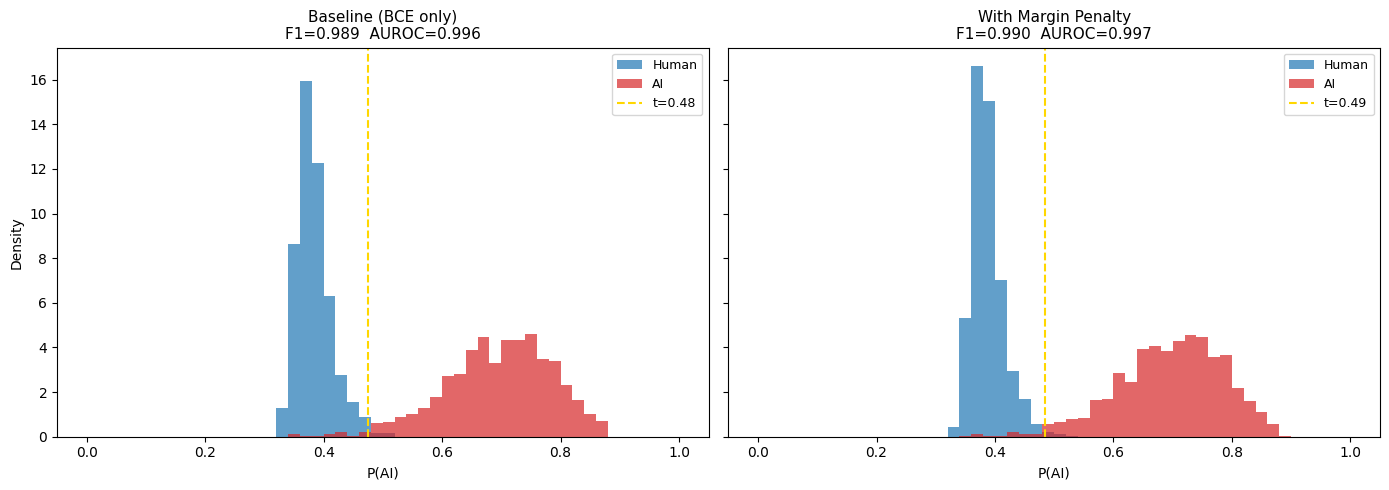

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
bins = np.linspace(0, 1, 51)

for ax, probs, metrics, title in [
    (axes[0], baseline_probs, baseline_metrics, "Baseline (BCE only)"),
    (axes[1], margin_probs, margin_metrics, "With Margin Penalty"),
]:
    ax.hist(probs[labels == 0], bins=bins, alpha=0.7, density=True, label="Human", color="tab:blue")
    ax.hist(probs[labels == 1], bins=bins, alpha=0.7, density=True, label="AI", color="tab:red")
    ax.axvline(metrics["threshold"], color="gold", linestyle="--", linewidth=1.5, label=f"t={metrics['threshold']:.2f}")
    ax.set_title(f"{title}\nF1={metrics['f1']:.3f}  AUROC={metrics['auroc']:.3f}", fontsize=11)
    ax.set_xlabel("P(AI)")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Density")
fig.tight_layout()
plt.show()

## Logit Distributions

Same comparison in logit space, where the margin penalty directly operates.

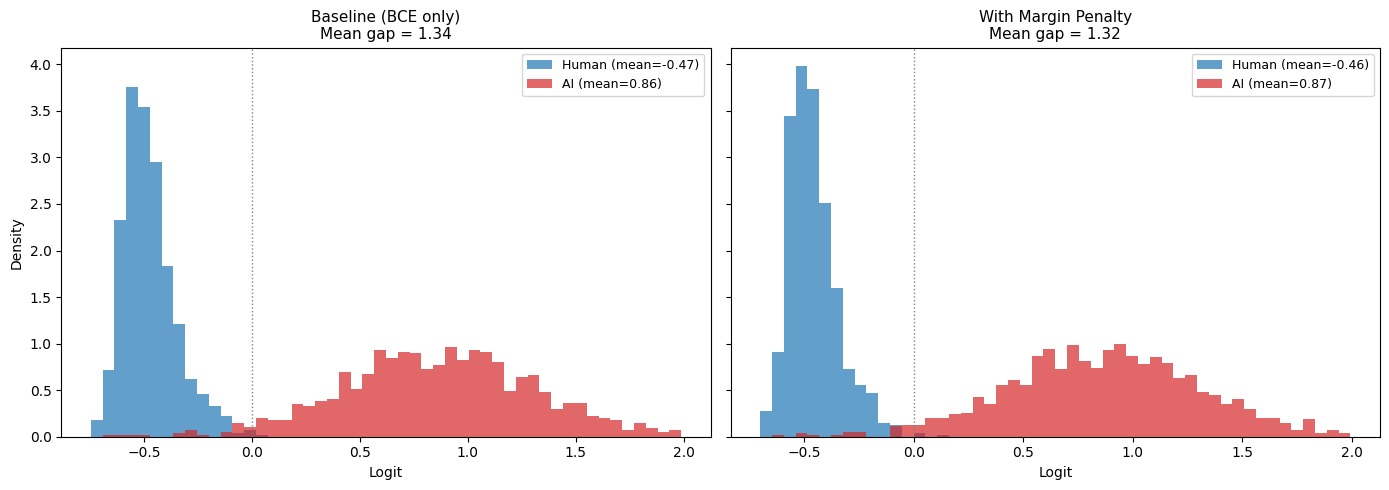

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, logits, title in [
    (axes[0], baseline_logits, "Baseline (BCE only)"),
    (axes[1], margin_logits, "With Margin Penalty"),
]:
    human_logits = logits[labels == 0]
    ai_logits = logits[labels == 1]
    gap = ai_logits.mean() - human_logits.mean()

    all_vals = np.concatenate([human_logits, ai_logits])
    bins = np.linspace(all_vals.min(), all_vals.max(), 51)

    ax.hist(human_logits, bins=bins, alpha=0.7, density=True, label=f"Human (mean={human_logits.mean():.2f})", color="tab:blue")
    ax.hist(ai_logits, bins=bins, alpha=0.7, density=True, label=f"AI (mean={ai_logits.mean():.2f})", color="tab:red")
    ax.axvline(0, color="gray", linestyle=":", linewidth=1)
    ax.set_title(f"{title}\nMean gap = {gap:.2f}", fontsize=11)
    ax.set_xlabel("Logit")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Density")
fig.tight_layout()
plt.show()

## ROC Curves

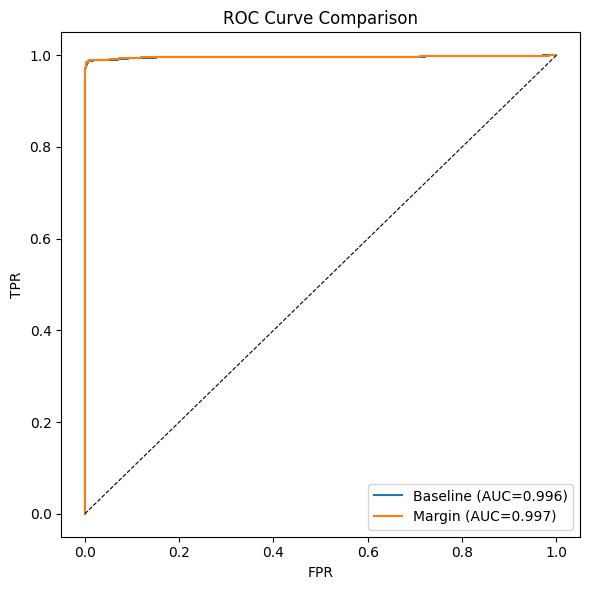

In [28]:
fig, ax = plt.subplots(figsize=(6, 6))

for probs, metrics, label in [
    (baseline_probs, baseline_metrics, "Baseline"),
    (margin_probs, margin_metrics, "Margin"),
]:
    fpr, tpr, _ = roc_curve(labels, probs)
    ax.plot(fpr, tpr, label=f"{label} (AUC={metrics['auroc']:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set(title="ROC Curve Comparison", xlabel="FPR", ylabel="TPR")
ax.legend()
fig.tight_layout()
plt.show()